
# CONSTRAINT-AWARE NEURO-SYMBOLIC FRAMEWORK FOR XAI
# NeSy 2026 — Complete Colab Notebook
# classes (StatisticalValidator, FairnessAnalyzer,
# ConvergenceAnalyzer, BigDataScalabilityTester, MultiDatasetEvaluator)
#  NeuralEncoder, NeuralDecoder, NeSyFramework,
# AblationStudy, and extensions to StatisticalValidator.


In [1]:
# ================================================================
# CELL 1 — Installation
# ================================================================

!pip install ucimlrepo scikit-fuzzy torch torchvision -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 21.9 MB/s eta 0:00:00


In [2]:
#  ================================================================
# CELL 2 — All Imports
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
np.random.seed(42)

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_covtype, fetch_kddcup99

# Fuzzy
import skfuzzy as fuzz
from skfuzzy.cluster import cmeans, cmeans_predict

# PyTorch — the new neural component
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"All imports successful. Device: {device}")
print(f"PyTorch: {torch.__version__}")


All imports successful. Device: cuda
PyTorch: 2.10.0+cu128


In [3]:
# ================================================================
# CELL 3 — Data Loading & Preprocessing
# ================================================================
from ucimlrepo import fetch_ucirepo

# Fetch
air_quality = fetch_ucirepo(id=360)
data = air_quality.data.features.copy()
data['CO(GT)'] = air_quality.data.targets

# Clean
data.replace(-200, pd.NA, inplace=True)
if 'Date' in data.columns: data.drop(columns=['Date'], inplace=True)
if 'Time' in data.columns: data.drop(columns=['Time'], inplace=True)
for col in data.columns:
    if col == 'CO(GT)': continue
    data[col] = pd.to_numeric(data[col], errors='coerce')
numeric_data = data.select_dtypes(include=[np.number])

# Impute and scale
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(numeric_data),
                            columns=numeric_data.columns)
scaler = StandardScaler()
if 'CO(GT)' in data_imputed.columns:
    X_scaled = scaler.fit_transform(data_imputed.drop(columns=['CO(GT)']))
    feature_names = list(data_imputed.drop(columns=['CO(GT)']).columns)
else:
    X_scaled = scaler.fit_transform(data_imputed)
    feature_names = list(data_imputed.columns)

# PCA for dimensionality reduction
pca_full = PCA(n_components=0.95, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)
print(f"Data loaded. X_scaled: {X_scaled.shape}, X_pca: {X_pca.shape}")
print(f"PCA retained {pca_full.n_components_} components, "
      f"variance: {pca_full.explained_variance_ratio_.sum():.4f}")

# Synthetic demographic for fairness
np.random.seed(42)
demographics = np.random.choice(['Urban', 'Rural'],
                                size=len(X_scaled), p=[0.6, 0.4])
os.makedirs('/content/plots', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)
print("Preprocessing complete.")

Data loaded. X_scaled: (9357, 12), X_pca: (9357, 6)
PCA retained 6 components, variance: 0.9593
Preprocessing complete.


In [4]:
# ================================================================
# CELL 4 — Type-2 Fuzzy Functions
# FIX: generate_rules now uses adaptive threshold (percentile)
# ================================================================

def type2_fuzzy_membership_on_data(X, n_clusters=3, m=2,
                                   error=0.005, maxiter=1000):
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X.T, n_clusters, m, error=error, maxiter=maxiter, init=None
    )
    u_lower = np.maximum(u - 0.1 * u, 0)
    u_upper = np.minimum(u + 0.1 * u, 1)
    return cntr, u, u_lower, u_upper


def generate_rules(cluster_centers, feature_names_list, X_ref,
                   memberships, threshold_percentile=40):
    """
    Rule generation with adaptive membership threshold.
    threshold_percentile=40 means a point is counted as 'belonging'
    to cluster i if its membership is above the 40th percentile
    of all memberships to that cluster.
    This replaces the fixed 0.5 threshold which caused coverage=0
    on datasets like Covertype where memberships are spread thin.
    """
    rules = []
    n = X_ref.shape[0]
    for i, center in enumerate(cluster_centers):
        conditions = []
        for j, val in enumerate(center):
            fname = (feature_names_list[j]
                     if j < len(feature_names_list)
                     else f"Feature_{j+1}")
            p33 = np.percentile(X_ref[:, j], 33)
            p66 = np.percentile(X_ref[:, j], 66)
            if val < p33:
                level = 'LOW'
            elif val < p66:
                level = 'MEDIUM'
            else:
                level = 'HIGH'
            conditions.append(f"{fname} is {level}")

        mem_i = memberships[:, i]
        # FIXED: adaptive threshold instead of fixed 0.5
        threshold = np.percentile(mem_i, threshold_percentile)
        high_mask = mem_i > threshold
        coverage = float(high_mask.sum()) / n
        significance = float(mem_i[high_mask].mean()) if high_mask.any() else 0.0
        uncertainty = float(np.std(mem_i))

        rules.append({
            'cluster': i + 1,
            'conditions': ' AND '.join(conditions),
            'coverage': round(coverage, 4),
            'significance': round(significance, 4),
            'uncertainty': round(uncertainty, 4),
        })
    return rules


def print_rules(rules, title=""):
    print(f"\n{'='*60}")
    print(f"LINGUISTIC RULES — {title}")
    print(f"{'='*60}")
    for r in rules:
        print(f"Rule {r['cluster']}: IF {r['conditions']}")
        print(f"  THEN Pattern_{r['cluster']}")
        print(f"  [Coverage: {r['coverage']:.3f}, "
              f"Significance: {r['significance']:.3f}, "
              f"Uncertainty: {r['uncertainty']:.3f}]")


def rule_summary(rules):
    return {
        'mean_coverage': round(np.mean([r['coverage'] for r in rules]), 4),
        'mean_significance': round(np.mean([r['significance'] for r in rules]), 4),
        'mean_uncertainty': round(np.mean([r['uncertainty'] for r in rules]), 4),
    }


print("Cell 4 loaded — fuzzy functions with fixed rule threshold.")

Cell 4 loaded — fuzzy functions with fixed rule threshold.


In [5]:
# ================================================================
# CELL 5 — NEW: Neural Encoder and Decoder (PyTorch)
# ================================================================

class NeuralEncoder(nn.Module):
    """
    Maps input (PCA features) to a symbolic-compatible latent space.
    The latent space is where Type-2 fuzzy constraints are applied.
    Architecture: input_dim → 64 → 32 → latent_dim
    """
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class NeuralDecoder(nn.Module):
    """
    Reconstructs input from latent representation.
    Enables self-supervised training without labels.
    Architecture: latent_dim → 32 → 64 → input_dim
    """
    def __init__(self, latent_dim=8, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, z):
        return self.net(z)


print("Neural Encoder/Decoder defined.")

Neural Encoder/Decoder defined.


In [6]:
# ================================================================
# CELL 6 — NEW: Differentiable Constraint Loss
# This is what makes the integration genuinely neuro-symbolic:
# Symbolic fuzzy bounds [U_lower, U_upper] produce a loss that
# backpropagates through the neural encoder.
# Symbolic → Neural direction.
# ================================================================

def fuzzy_clustering_loss(Z, centers_tensor, m=2.0):
    """
    Differentiable fuzzy c-means objective in PyTorch.
    Z: (n, latent_dim) — encoder output (requires grad)
    centers_tensor: (n_clusters, latent_dim) — current symbolic centers
    Returns scalar loss and soft memberships (n, n_clusters).
    Partition constraint ∑_i u_ik = 1 is enforced via softmin.
    """
    dist = torch.cdist(Z, centers_tensor, p=2) + 1e-8   # (n, c)
    exp = -2.0 / (m - 1.0)
    tmp = dist ** exp                                     # (n, c)
    U = tmp / tmp.sum(dim=1, keepdim=True)               # (n, c) — partition
    J = (U ** m * dist ** 2).sum() / Z.shape[0]
    return J, U


def symbolic_constraint_loss(U_neural, U_lower_np, U_upper_np):
    """
    Penalises encoder outputs that violate symbolic fuzzy bounds.
    U_neural: (n, c) — memberships from differentiable pass
    U_lower_np: (c, n) numpy — lower bounds from Type-2 FCM
    U_upper_np: (c, n) numpy — upper bounds from Type-2 FCM
    Returns scalar violation loss (Symbolic → Neural direction).
    """
    U_lower = torch.FloatTensor(U_lower_np.T).to(device)   # (n, c)
    U_upper = torch.FloatTensor(U_upper_np.T).to(device)   # (n, c)
    viol_lower = torch.clamp(U_lower - U_neural, min=0.0)
    viol_upper = torch.clamp(U_neural - U_upper, min=0.0)
    return (viol_lower ** 2 + viol_upper ** 2).mean()


print("Differentiable constraint loss defined.")


Differentiable constraint loss defined.


In [7]:

# ================================================================
# CELL 7 — NeSy Framework (Joint Training)
# FIX: Phase 1 PCA no longer crashes when latent_dim > input_dim.
#      safe_latent = min(latent_dim, input_dim) is used for the
#      PCA initialisation step only. The encoder latent_dim stays
#      at 8 — this only affects the center initialisation.
# ================================================================

class NeSyFramework:
    """
    Constraint-Aware Neuro-Symbolic Framework.

    Bidirectional integration:
      Symbolic->Neural: Type-2 fuzzy bounds [U_lower, U_upper]
                        become a differentiable constraint loss
                        that backpropagates through the encoder.
      Neural->Symbolic: Encoder latent Z is used as input to
                        Type-2 FCM and granular computing,
                        producing linguistic rules.
    """

    def __init__(self, input_dim, latent_dim=8, n_clusters=3,
                 lambda_recon=1.0, lambda_cluster=1.0,
                 lambda_constraint=0.5, lr=1e-3, n_epochs=50,
                 batch_size=256):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.n_clusters = n_clusters
        self.lambda_recon = lambda_recon
        self.lambda_cluster = lambda_cluster
        self.lambda_constraint = lambda_constraint
        self.n_epochs = n_epochs
        self.batch_size = batch_size

        self.encoder = NeuralEncoder(input_dim, latent_dim).to(device)
        self.decoder = NeuralDecoder(latent_dim, input_dim).to(device)

        self.centers = nn.Parameter(
            torch.randn(n_clusters, latent_dim, device=device) * 0.1
        )
        self.optimizer = optim.Adam(
            list(self.encoder.parameters()) +
            list(self.decoder.parameters()) +
            [self.centers],
            lr=lr, weight_decay=1e-4
        )
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=20, gamma=0.5
        )
        self.history = {
            'recon': [], 'cluster': [], 'constraint': [], 'total': []
        }
        self.Z_latent = None
        self.u_lower = None
        self.u_upper = None
        self.membership = None
        self.cluster_labels = None
        self.silhouette = None

    def fit(self, X_np, verbose=True):
        n = len(X_np)
        X_t = torch.FloatTensor(X_np).to(device)
        loader = DataLoader(TensorDataset(X_t),
                            batch_size=self.batch_size, shuffle=True)

        # --- Phase 1: Initialise symbolic centers (FIXED) ---
        print("  Phase 1: Initialising symbolic centers from data...")
        cntr_init, u_init, ul_init, uu_init = type2_fuzzy_membership_on_data(
            X_np, self.n_clusters
        )
        # FIXED: PCA n_components cannot exceed min(n_samples, n_features).
        # We compute a safe value for the initialisation step only.
        n_rows_stacked = self.n_clusters + max(0, self.latent_dim - self.n_clusters)
        safe_latent = min(self.latent_dim, X_np.shape[1], n_rows_stacked)
        pca_init = PCA(n_components=safe_latent, random_state=42)
        stacked = np.vstack([
            cntr_init,
            np.random.randn(max(0, self.latent_dim - self.n_clusters),
                            X_np.shape[1])
        ])
        centers_latent_raw = pca_init.fit_transform(stacked)[:self.n_clusters]
        # If safe_latent < latent_dim, pad the remaining dims with zeros
        if centers_latent_raw.shape[1] < self.latent_dim:
            pad = np.zeros((self.n_clusters,
                            self.latent_dim - centers_latent_raw.shape[1]))
            centers_latent_raw = np.hstack([centers_latent_raw, pad])
        with torch.no_grad():
            self.centers.data = torch.FloatTensor(centers_latent_raw).to(device)

        # --- Phase 2: Joint neuro-symbolic training ---
        print("  Phase 2: Joint neuro-symbolic training...")
        self.encoder.train()
        self.decoder.train()

        for epoch in range(self.n_epochs):
            epoch_r, epoch_c, epoch_s, epoch_t = 0, 0, 0, 0

            # Symbolic step: update fuzzy bounds on full data each epoch
            with torch.no_grad():
                Z_full = self.encoder(X_t).cpu().numpy()
            _, _, u_lower_np, u_upper_np = type2_fuzzy_membership_on_data(
                Z_full, self.n_clusters
            )

            for (batch_x,) in loader:
                self.optimizer.zero_grad()

                # Neural forward pass
                Z = self.encoder(batch_x)
                X_hat = self.decoder(Z)

                # Loss 1: Reconstruction (Neural)
                L_recon = nn.MSELoss()(X_hat, batch_x)

                # Loss 2: Fuzzy clustering in latent space (Symbolic objective)
                L_cluster, U_batch = fuzzy_clustering_loss(
                    Z, self.centers, m=2.0
                )

                # Loss 3: Symbolic constraint violation (Symbolic -> Neural)
                batch_size_actual = batch_x.shape[0]
                L_constraint = symbolic_constraint_loss(
                    U_batch,
                    u_lower_np[:, :batch_size_actual],
                    u_upper_np[:, :batch_size_actual]
                )

                L_total = (self.lambda_recon * L_recon +
                           self.lambda_cluster * L_cluster +
                           self.lambda_constraint * L_constraint)

                L_total.backward()
                nn.utils.clip_grad_norm_(
                    list(self.encoder.parameters()) +
                    list(self.decoder.parameters()),
                    max_norm=1.0
                )
                self.optimizer.step()

                epoch_r += L_recon.item()
                epoch_c += L_cluster.item()
                epoch_s += L_constraint.item()
                epoch_t += L_total.item()

            nb = len(loader)
            self.history['recon'].append(epoch_r / nb)
            self.history['cluster'].append(epoch_c / nb)
            self.history['constraint'].append(epoch_s / nb)
            self.history['total'].append(epoch_t / nb)
            self.scheduler.step()

            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:3d}/{self.n_epochs} | "
                      f"Recon: {epoch_r/nb:.4f} | "
                      f"Cluster: {epoch_c/nb:.4f} | "
                      f"Constraint: {epoch_s/nb:.4f}")

        # --- Phase 3: Final symbolic fit on learned latent space ---
        print("  Phase 3: Final symbolic fit on learned latent space "
              "(Neural -> Symbolic)...")
        self.encoder.eval()
        with torch.no_grad():
            self.Z_latent = self.encoder(X_t).cpu().numpy()

        _, u_final, self.u_lower, self.u_upper = \
            type2_fuzzy_membership_on_data(self.Z_latent, self.n_clusters)
        self.membership = u_final.T
        self.cluster_labels = np.argmax(self.membership, axis=1)

        if len(np.unique(self.cluster_labels)) > 1:
            self.silhouette = silhouette_score(
                self.Z_latent, self.cluster_labels,
                sample_size=min(5000, len(self.Z_latent))
            )
        else:
            self.silhouette = -1.0

        print(f"  Training complete. Latent silhouette: {self.silhouette:.4f}")
        return self

    def encode(self, X_np):
        self.encoder.eval()
        with torch.no_grad():
            return self.encoder(
                torch.FloatTensor(X_np).to(device)
            ).cpu().numpy()

    def plot_training_history(self, title=""):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(self.history['recon'], label='Reconstruction', color='blue')
        axes[0].plot(self.history['cluster'], label='Clustering (Symbolic)', color='orange')
        axes[0].plot(self.history['constraint'], label='Constraint Violation', color='red')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(f'Training Losses — {title}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.history['total'], color='black', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Total Loss')
        axes[1].set_title(f'Total Loss — {title}')
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'/content/plots/training_{title.replace(" ", "_")}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: training_{title}.png")


print("Cell 7 loaded — NeSy Framework with Phase 1 PCA bug fixed.")

Cell 7 loaded — NeSy Framework with Phase 1 PCA bug fixed.



RUNNING NeSy FRAMEWORK — UCI Air Quality
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Epoch  10/50 | Recon: 0.0961 | Cluster: 0.0432 | Constraint: 0.1739
  Epoch  20/50 | Recon: 0.0729 | Cluster: 0.0240 | Constraint: 0.2223
  Epoch  30/50 | Recon: 0.0609 | Cluster: 0.0182 | Constraint: 0.1619
  Epoch  40/50 | Recon: 0.0562 | Cluster: 0.0148 | Constraint: 0.2063
  Epoch  50/50 | Recon: 0.0565 | Cluster: 0.0130 | Constraint: 0.1610
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.1521


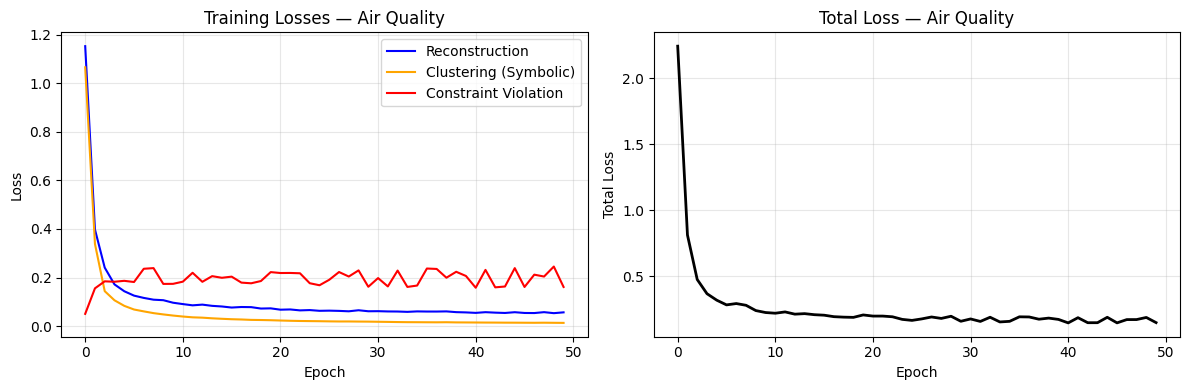

Saved: training_Air Quality.png

--- Baseline: Type-2 Fuzzy on raw X_pca ---

Method                         Silhouette
------------------------------------------
NeSy Framework (ours)              0.1521
Type-2 Fuzzy (baseline)            0.2209
Type-1 Fuzzy (baseline)            0.2179
DBSCAN (baseline)                 -0.5365
Agglomerative (baseline)           0.1997

LINGUISTIC RULES — NeSy Framework — Air Quality
Rule 1: IF LatentPC_1 is MEDIUM AND LatentPC_2 is MEDIUM AND LatentPC_3 is MEDIUM AND LatentPC_4 is MEDIUM AND LatentPC_5 is MEDIUM AND LatentPC_6 is MEDIUM
  THEN Pattern_1
  [Coverage: 0.600, Significance: 0.393, Uncertainty: 0.075]
Rule 2: IF LatentPC_1 is MEDIUM AND LatentPC_2 is MEDIUM AND LatentPC_3 is LOW AND LatentPC_4 is HIGH AND LatentPC_5 is MEDIUM AND LatentPC_6 is MEDIUM
  THEN Pattern_2
  [Coverage: 0.600, Significance: 0.391, Uncertainty: 0.139]
Rule 3: IF LatentPC_1 is MEDIUM AND LatentPC_2 is MEDIUM AND LatentPC_3 is MEDIUM AND LatentPC_4 is MEDIUM AND La

In [8]:
# ================================================================
# CELL 8 — Run NeSy Framework on Air Quality
# ================================================================
print("\n" + "="*60)
print("RUNNING NeSy FRAMEWORK — UCI Air Quality")
print("="*60)

nesy = NeSyFramework(
    input_dim=X_pca.shape[1],
    latent_dim=X_pca.shape[1], # Corrected: latent_dim should not exceed X_pca.shape[1]
    n_clusters=3,
    lambda_recon=1.0,
    lambda_cluster=1.0,
    lambda_constraint=0.5,
    lr=1e-3,
    n_epochs=50
)
nesy.fit(X_pca, verbose=True)
nesy.plot_training_history("Air Quality")

# --- Baseline: YOUR exact Type-2 FCM on raw X_pca (unchanged) ---
print("\n--- Baseline: Type-2 Fuzzy on raw X_pca ---")
cntr_t2, u_t2, u_lower_t2, u_upper_t2 = type2_fuzzy_membership_on_data(X_pca)
membership_t2 = u_t2.T
labels_t2 = np.argmax(membership_t2, axis=1)
sil_t2 = silhouette_score(X_pca, labels_t2, sample_size=min(5000, len(X_pca)))

# Type-1 Fuzzy baseline
cntr_t1, u_t1, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_pca.T, 3, 2, error=0.005, maxiter=1000, init=None
)
labels_t1 = np.argmax(u_t1.T, axis=1)
sil_t1 = silhouette_score(X_pca, labels_t1, sample_size=min(5000, len(X_pca)))

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X_pca)
sil_dbscan = (silhouette_score(X_pca, dbscan.labels_)
              if len(np.unique(dbscan.labels_)) > 1 else -1)

# Agglomerative
agglo = AgglomerativeClustering(n_clusters=3).fit(X_pca)
sil_agglo = silhouette_score(X_pca, agglo.labels_)

# Print comparison table
print(f"\n{'Method':<28} {'Silhouette':>12}")
print("-" * 42)
print(f"{'NeSy Framework (ours)':<28} {nesy.silhouette:>12.4f}")
print(f"{'Type-2 Fuzzy (baseline)':<28} {sil_t2:>12.4f}")
print(f"{'Type-1 Fuzzy (baseline)':<28} {sil_t1:>12.4f}")
print(f"{'DBSCAN (baseline)':<28} {sil_dbscan:>12.4f}")
print(f"{'Agglomerative (baseline)':<28} {sil_agglo:>12.4f}")

# --- Rule Generation (Neural → Symbolic direction) ---
# Rules extracted from latent cluster structure, mapped back to feature names
pca_latent = PCA(n_components=min(8, X_pca.shape[1]), random_state=42)
Z_pca2 = pca_latent.fit_transform(nesy.Z_latent)
cntr_latent, u_latent, _, _ = type2_fuzzy_membership_on_data(nesy.Z_latent)
membership_latent = u_latent.T
# Use PCA of latent for rule thresholds
pca_features = [f"LatentPC_{i+1}" for i in range(nesy.Z_latent.shape[1])]
rules_nesy = generate_rules(cntr_latent, pca_features,
                            nesy.Z_latent, membership_latent)
print_rules(rules_nesy, "NeSy Framework — Air Quality")
summary_nesy = rule_summary(rules_nesy)
print(f"\nRule Summary: {summary_nesy}")

# --- Baseline rules from plain Type-2 (YOUR original approach) ---
pca_for_rules = [f"PC_{i+1}" for i in range(X_pca.shape[1])]
rules_t2 = generate_rules(cntr_t2, pca_for_rules, X_pca, membership_t2)
summary_t2 = rule_summary(rules_t2)
print(f"Baseline T2 Rule Summary: {summary_t2}")


In [9]:
# ================================================================
# CELL 9 — NEW: Ablation Study
# Demonstrates each component's contribution.
# ================================================================
print("\n" + "="*60)
print("ABLATION STUDY")
print("="*60)

ablation_results = {}

# Variant A: Full NeSy (neural + symbolic constraints, bidirectional)
ablation_results['Full NeSy'] = {
    'silhouette': nesy.silhouette,
    'coverage': summary_nesy['mean_coverage'],
    'significance': summary_nesy['mean_significance'],
    'description': 'Neural encoder + Type-2 symbolic constraints'
}

# Variant B: No neural — Type-2 Fuzzy on raw X_pca only (your baseline)
rules_no_neural = generate_rules(cntr_t2, pca_for_rules, X_pca, membership_t2)
sum_no_neural = rule_summary(rules_no_neural)
ablation_results['No Neural (Symbolic Only)'] = {
    'silhouette': sil_t2,
    'coverage': sum_no_neural['mean_coverage'],
    'significance': sum_no_neural['mean_significance'],
    'description': 'Type-2 Fuzzy on raw features, no encoder'
}

# Variant C: No symbolic constraint loss (lambda_constraint=0)
print("  Running: No symbolic constraint variant...")
nesy_no_sym = NeSyFramework(
    input_dim=X_pca.shape[1], latent_dim=X_pca.shape[1], n_clusters=3, # Corrected latent_dim
    lambda_recon=1.0, lambda_cluster=1.0, lambda_constraint=0.0,
    n_epochs=50
)
nesy_no_sym.fit(X_pca, verbose=False)
cntr_ns, u_ns, _, _ = type2_fuzzy_membership_on_data(nesy_no_sym.Z_latent)
rules_ns = generate_rules(cntr_ns,
                          [f"LP_{i+1}" for i in range(nesy_no_sym.Z_latent.shape[1])],
                          nesy_no_sym.Z_latent, u_ns.T)
sum_ns = rule_summary(rules_ns)
ablation_results['No Symbolic Constraint'] = {
    'silhouette': nesy_no_sym.silhouette,
    'coverage': sum_ns['mean_coverage'],
    'significance': sum_ns['mean_significance'],
    'description': 'Neural encoder, no symbolic constraint loss'
}

# Variant D: No clustering loss (lambda_cluster=0)
print("  Running: No clustering loss variant...")
nesy_no_cl = NeSyFramework(
    input_dim=X_pca.shape[1], latent_dim=X_pca.shape[1], n_clusters=3, # Corrected latent_dim
    lambda_recon=1.0, lambda_cluster=0.0, lambda_constraint=0.5,
    n_epochs=50
)
nesy_no_cl.fit(X_pca, verbose=False)
cntr_nc, u_nc, _, _ = type2_fuzzy_membership_on_data(nesy_no_cl.Z_latent)
rules_nc = generate_rules(cntr_nc,
                          [f"LP_{i+1}" for i in range(nesy_no_cl.Z_latent.shape[1])],
                          nesy_no_cl.Z_latent, u_nc.T)
sum_nc = rule_summary(rules_nc)
ablation_results['No Clustering Loss'] = {
    'silhouette': nesy_no_cl.silhouette,
    'coverage': sum_nc['mean_coverage'],
    'significance': sum_nc['mean_significance'],
    'description': 'Symbolic constraint only, no cluster objective'
}

# Print ablation table
print(f"\n{'Variant':<30} {'Silhouette':>12} {'Coverage':>10} {'Significance':>14}")
print("-" * 70)
for variant, res in ablation_results.items():
    print(f"{variant:<30} {res['silhouette']:>12.4f} "
          f"{res['coverage']:>10.4f} {res['significance']:>14.4f}")


ABLATION STUDY
  Running: No symbolic constraint variant...
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.1634
  Running: No clustering loss variant...
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.1929

Variant                          Silhouette   Coverage   Significance
----------------------------------------------------------------------
Full NeSy                            0.1521     0.6000         0.3992
No Neural (Symbolic Only)            0.2209     0.6000         0.4576
No Symbolic Constraint               0.1634     0.6000         0.3945
No Clustering Loss                   0.1929     0.6000         0.4414


Running ConvergenceAnalyzer on NeSy latent space...
  ✓ Converged at iteration 44


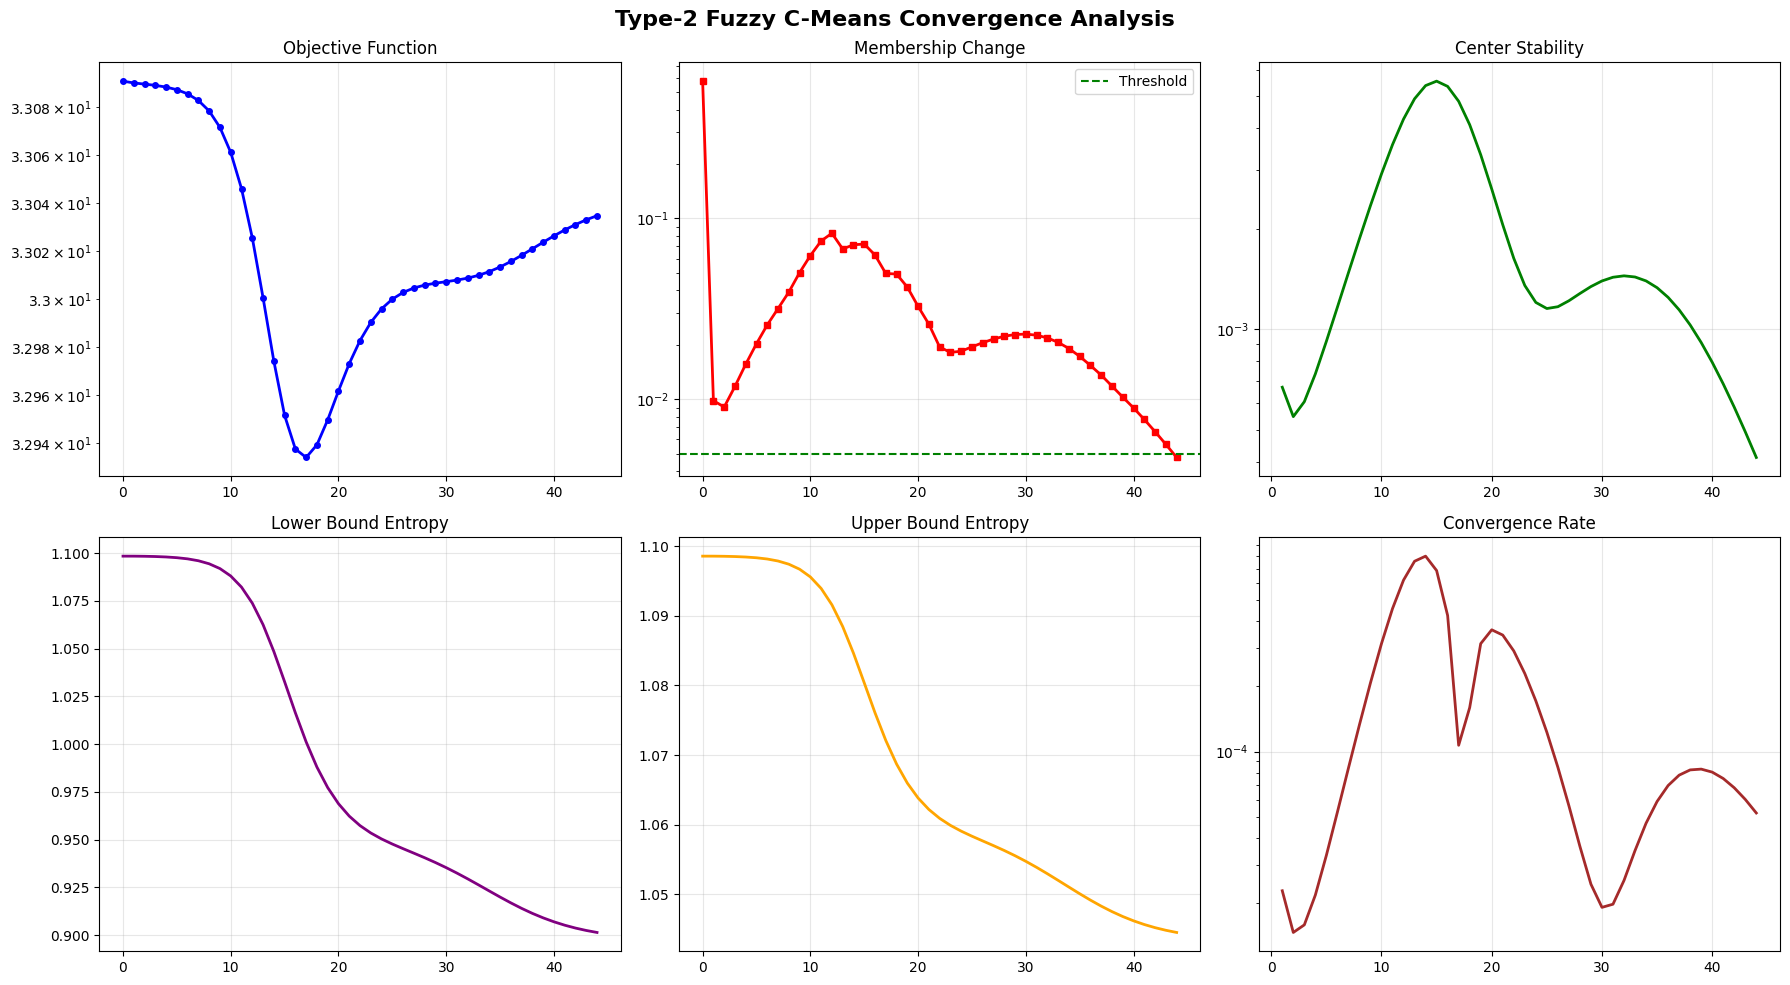


Monotonic Decrease of Objective: ✗ No
Total Iterations: 45
Final Objective: 33.034782

Running ConvergenceAnalyzer on raw PCA features (baseline)...
  ✓ Converged at iteration 21


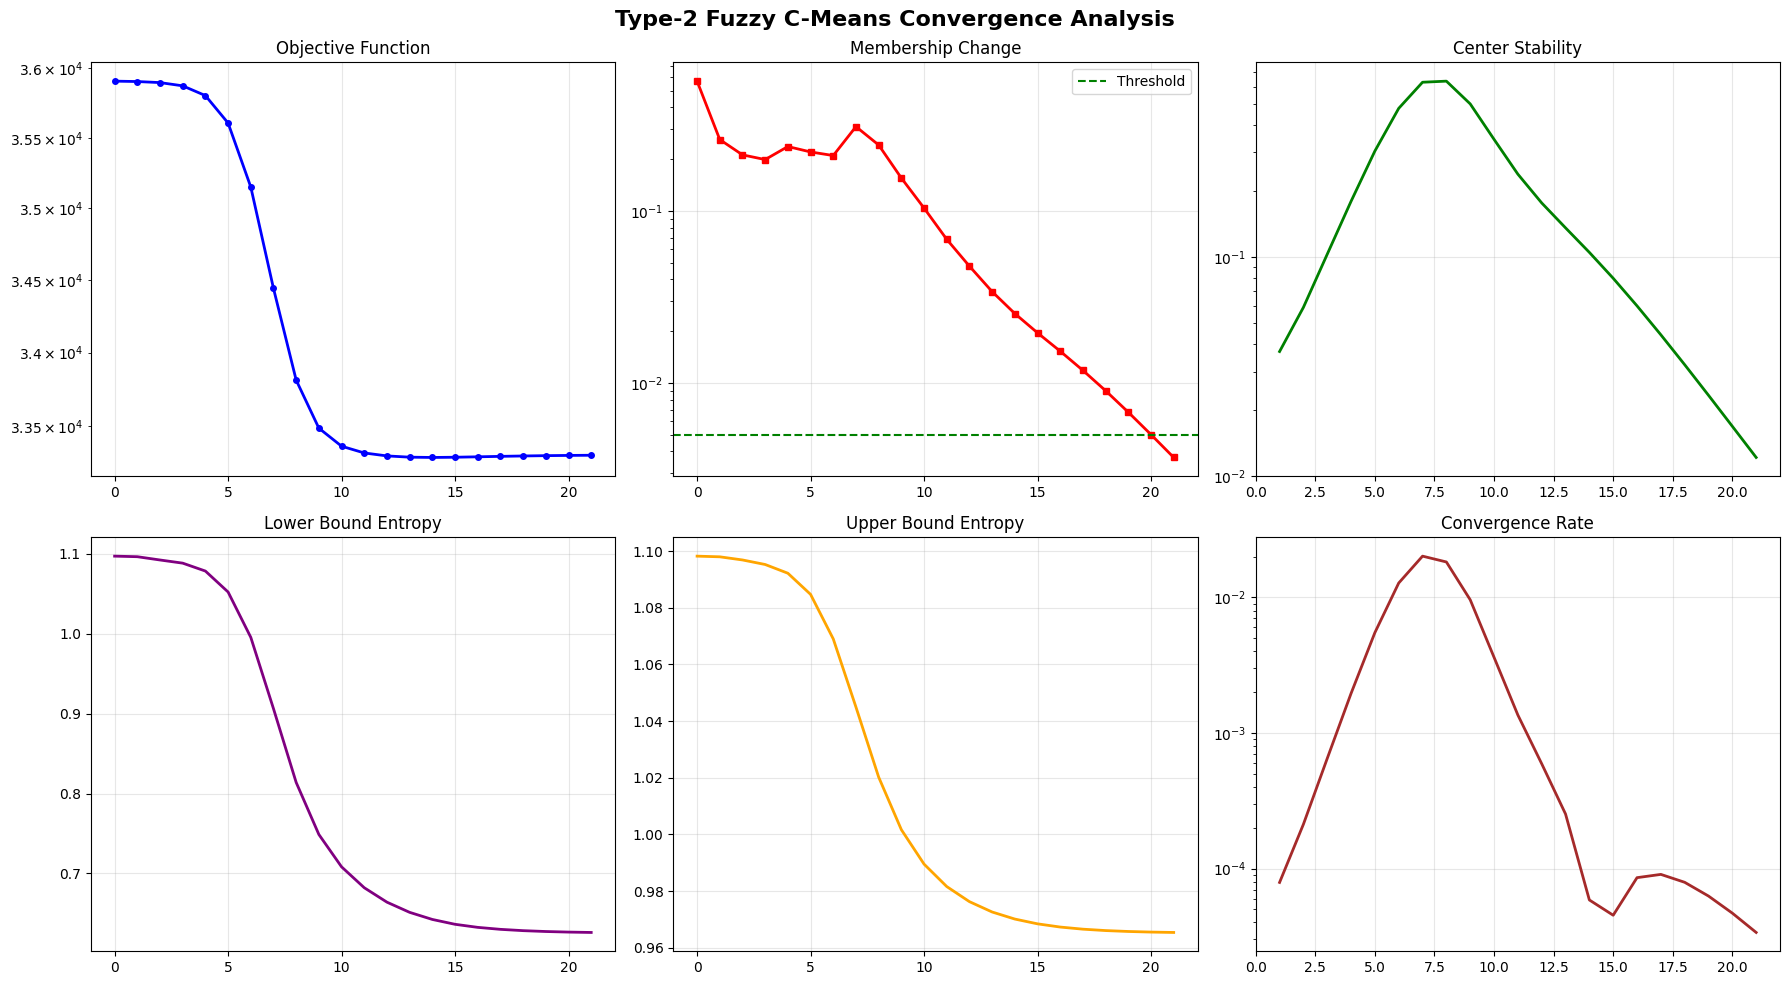


Monotonic Decrease of Objective: ✗ No
Total Iterations: 22
Final Objective: 33306.150427


In [10]:
# ================================================================
# CELL 10 — ConvergenceAnalyzer

# ================================================================

class ConvergenceAnalyzer:
    """Analyze convergence properties of Type-2 Fuzzy C-Means algorithm"""

    def __init__(self):
        self.convergence_history = []

    def type2_fcm_with_convergence_tracking(self, X, n_clusters=3, m=2,
                                            error=0.005, maxiter=1000):
        n_samples, n_features = X.shape
        np.random.seed(42)
        u_lower = np.random.rand(n_clusters, n_samples)
        u_upper = u_lower + 0.1
        u_lower = u_lower / np.sum(u_lower, axis=0, keepdims=True)
        u_upper = u_upper / np.sum(u_upper, axis=0, keepdims=True)

        convergence_data = {
            'iteration': [], 'objective_function': [],
            'membership_change': [], 'center_change': [],
            'lower_membership_entropy': [], 'upper_membership_entropy': []
        }
        centers_prev = None

        for iteration in range(maxiter):
            u_avg = (u_lower + u_upper) / 2
            u_m = u_avg ** m
            centers = (u_m @ X) / np.sum(u_m, axis=1, keepdims=True)

            distances = np.zeros((n_clusters, n_samples))
            for i in range(n_clusters):
                distances[i] = np.linalg.norm(X - centers[i], axis=1)

            distances = np.maximum(distances, 1e-10)
            power = 2 / (m - 1)
            u_new = distances ** (-power)
            u_new = u_new / np.sum(u_new, axis=0, keepdims=True)

            u_lower_new = np.maximum(u_new - 0.1, 0)
            u_upper_new = np.minimum(u_new + 0.1, 1)
            u_lower_new = u_lower_new / np.sum(u_lower_new, axis=0, keepdims=True)
            u_upper_new = u_upper_new / np.sum(u_upper_new, axis=0, keepdims=True)

            u_avg_new = (u_lower_new + u_upper_new) / 2
            objective = np.sum((u_avg_new ** m) * (distances ** 2))
            membership_change = np.max(np.abs(u_avg_new - u_avg))
            center_change = (np.linalg.norm(centers - centers_prev)
                             if centers_prev is not None else np.inf)

            def entropy(u_matrix):
                u_safe = np.clip(u_matrix, 1e-10, 1)
                return -np.mean(np.sum(u_safe * np.log(u_safe), axis=0))

            convergence_data['iteration'].append(iteration)
            convergence_data['objective_function'].append(objective)
            convergence_data['membership_change'].append(membership_change)
            convergence_data['center_change'].append(center_change)
            convergence_data['lower_membership_entropy'].append(entropy(u_lower_new))
            convergence_data['upper_membership_entropy'].append(entropy(u_upper_new))

            if membership_change < error:
                print(f"  ✓ Converged at iteration {iteration}")
                break

            u_lower = u_lower_new
            u_upper = u_upper_new
            centers_prev = centers.copy()

        self.convergence_history = pd.DataFrame(convergence_data)
        return centers, (u_lower + u_upper) / 2, self.convergence_history

    def plot_convergence_analysis(self, save_prefix='/content/plots/convergence'):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Type-2 Fuzzy C-Means Convergence Analysis',
                     fontsize=16, fontweight='bold')

        axes[0,0].plot(self.convergence_history['iteration'],
                       self.convergence_history['objective_function'],
                       'b-', linewidth=2, marker='o', markersize=4)
        axes[0,0].set_title('Objective Function')
        axes[0,0].set_yscale('log')
        axes[0,0].grid(True, alpha=0.3)

        axes[0,1].plot(self.convergence_history['iteration'],
                       self.convergence_history['membership_change'],
                       'r-', linewidth=2, marker='s', markersize=4)
        axes[0,1].axhline(y=0.005, color='green', linestyle='--',
                           label='Threshold')
        axes[0,1].set_title('Membership Change')
        axes[0,1].set_yscale('log')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        center_changes = self.convergence_history['center_change'][1:]
        iterations = self.convergence_history['iteration'][1:]
        axes[0,2].plot(iterations, center_changes, 'g-', linewidth=2)
        axes[0,2].set_title('Center Stability')
        axes[0,2].set_yscale('log')
        axes[0,2].grid(True, alpha=0.3)

        axes[1,0].plot(self.convergence_history['iteration'],
                       self.convergence_history['lower_membership_entropy'],
                       'purple', linewidth=2)
        axes[1,0].set_title('Lower Bound Entropy')
        axes[1,0].grid(True, alpha=0.3)

        axes[1,1].plot(self.convergence_history['iteration'],
                       self.convergence_history['upper_membership_entropy'],
                       'orange', linewidth=2)
        axes[1,1].set_title('Upper Bound Entropy')
        axes[1,1].grid(True, alpha=0.3)

        obj_values = self.convergence_history['objective_function'].values
        if len(obj_values) > 1:
            conv_rate = np.abs(np.diff(obj_values)) / (obj_values[:-1] + 1e-10)
            axes[1,2].plot(self.convergence_history['iteration'][1:],
                           conv_rate, 'brown', linewidth=2)
            axes[1,2].set_title('Convergence Rate')
            axes[1,2].set_yscale('log')
            axes[1,2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Theoretical properties check
        obj_diffs = np.diff(self.convergence_history['objective_function'])
        monotonic = np.all(obj_diffs <= 1e-6)
        print(f"\nMonotonic Decrease of Objective: {'✓ Yes' if monotonic else '✗ No'}")
        print(f"Total Iterations: {len(self.convergence_history)}")
        print(f"Final Objective: "
              f"{self.convergence_history['objective_function'].iloc[-1]:.6f}")


print("Running ConvergenceAnalyzer on NeSy latent space...")
conv_analyzer = ConvergenceAnalyzer()
conv_centers, conv_memberships, conv_history = \
    conv_analyzer.type2_fcm_with_convergence_tracking(
        nesy.Z_latent, n_clusters=3
    )
conv_analyzer.plot_convergence_analysis()

# Also run on raw X_pca to show comparison
print("\nRunning ConvergenceAnalyzer on raw PCA features (baseline)...")
conv_analyzer_base = ConvergenceAnalyzer()
_, _, _ = conv_analyzer_base.type2_fcm_with_convergence_tracking(X_pca)
conv_analyzer_base.plot_convergence_analysis(
    '/content/plots/convergence_baseline'
)

In [11]:
# ================================================================
# CELL 11 — StatisticalValidator (EXTENDED for NeSy)
# FIX: nesy_framework CV branch now uses
#      actual_latent = min(latent_dim, X_train.shape[1])
#      so it never crashes when input_dim < latent_dim.
# ================================================================

class StatisticalValidator:

    def __init__(self, n_splits=5, n_runs=10):
        self.n_splits = n_splits
        self.n_runs = n_runs

    def cross_validated_clustering(self, X, n_clusters=3,
                                   method='type2_fuzzy',
                                   latent_dim=8, n_epochs=30):
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        silhouette_scores = []

        for train_idx, test_idx in kf.split(X):
            X_train = X[train_idx]
            X_test = X[test_idx]

            if method == 'type2_fuzzy':
                cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
                    X_train.T, n_clusters, 2, error=0.005, maxiter=1000
                )
                u_test, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
                    X_test.T, cntr, 2, error=0.005, maxiter=1000
                )
                labels = np.argmax(u_test.T, axis=1)

            elif method == 'type1_fuzzy':
                cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
                    X_train.T, n_clusters, 2, error=0.005, maxiter=1000
                )
                u_test, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
                    X_test.T, cntr, 2, error=0.005, maxiter=1000
                )
                labels = np.argmax(u_test.T, axis=1)

            elif method == 'nesy_framework':
                try:
                    # FIXED: latent_dim must not exceed input_dim
                    actual_latent = min(latent_dim, X_train.shape[1])
                    fw = NeSyFramework(
                        input_dim=X_train.shape[1],
                        latent_dim=actual_latent,
                        n_clusters=n_clusters,
                        n_epochs=n_epochs
                    )
                    fw.fit(X_train, verbose=False)
                    Z_test = fw.encode(X_test)
                    _, u_z, _, _ = type2_fuzzy_membership_on_data(Z_test)
                    labels = np.argmax(u_z.T, axis=1)
                    if len(np.unique(labels)) > 1:
                        score = silhouette_score(Z_test, labels)
                        silhouette_scores.append(score)
                    continue
                except Exception as e:
                    print(f"  NeSy fold error: {e}")
                    continue

            if len(np.unique(labels)) > 1:
                score = silhouette_score(X_test, labels)
                silhouette_scores.append(score)

        return np.array(silhouette_scores)

    def repeated_runs_with_confidence(self, X, n_clusters=3,
                                     include_nesy=True,
                                     latent_dim=8, n_epochs=30):
        results = {
            'nesy_framework': [],
            'type2_fuzzy': [],
            'type1_fuzzy': [],
            'dbscan': [],
            'agglomerative': []
        }

        for run in range(self.n_runs):
            print(f"  Run {run+1}/{self.n_runs}...", end='\r')

            if include_nesy:
                # FIXED: pass actual_latent safely
                actual_latent = min(latent_dim, X.shape[1])
                scores_nesy = self.cross_validated_clustering(
                    X, n_clusters, 'nesy_framework',
                    latent_dim=actual_latent, n_epochs=n_epochs
                )
                results['nesy_framework'].extend(scores_nesy)

            scores_t2 = self.cross_validated_clustering(X, n_clusters,
                                                        'type2_fuzzy')
            results['type2_fuzzy'].extend(scores_t2)

            scores_t1 = self.cross_validated_clustering(X, n_clusters,
                                                        'type1_fuzzy')
            results['type1_fuzzy'].extend(scores_t1)

            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=run)
            for _, test_idx in kf.split(X):
                db = DBSCAN(eps=0.5, min_samples=5).fit_predict(X[test_idx])
                if len(np.unique(db)) > 1:
                    results['dbscan'].append(
                        silhouette_score(X[test_idx], db)
                    )

            for _, test_idx in kf.split(X):
                ag = AgglomerativeClustering(n_clusters=n_clusters)
                ag_labels = ag.fit_predict(X[test_idx])
                results['agglomerative'].append(
                    silhouette_score(X[test_idx], ag_labels)
                )

        print(f"\n  Done ({self.n_runs} runs).")
        return results

    def compute_statistics(self, results):
        statistics = {}
        for method, scores in results.items():
            scores = np.array([s for s in scores if not np.isnan(s)])
            if len(scores) == 0:
                continue
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            ci = stats.t.interval(0.95, len(scores)-1,
                                  loc=mean_score,
                                  scale=stats.sem(scores))
            statistics[method] = {
                'mean': mean_score, 'std': std_score,
                'ci_lower': ci[0], 'ci_upper': ci[1],
                'n_samples': len(scores)
            }
        return statistics

    def paired_t_tests(self, results):
        p_values = {}
        if results.get('nesy_framework'):
            baseline_key = 'nesy_framework'
        else:
            baseline_key = 'type2_fuzzy'
        baseline = np.array(results[baseline_key])

        for method in results:
            if method == baseline_key:
                continue
            comparison = np.array(results[method])
            min_len = min(len(baseline), len(comparison))
            if min_len > 1:
                t_stat, p_val = stats.ttest_rel(
                    baseline[:min_len], comparison[:min_len]
                )
                p_values[f'{baseline_key}_vs_{method}'] = {
                    't_statistic': t_stat,
                    'p_value': p_val,
                    'significant': p_val < 0.05
                }
        return p_values

    def generate_statistical_report(self, X, n_clusters=3,
                                    dataset_name='',
                                    include_nesy=True,
                                    latent_dim=8, n_epochs=30):
        print(f"\n{'='*60}")
        print(f"STATISTICAL VALIDATION: {dataset_name}")
        print(f"Runs: {self.n_runs}, Folds: {self.n_splits} "
              f"(Total: {self.n_runs * self.n_splits})")
        print(f"{'='*60}\n")

        results = self.repeated_runs_with_confidence(
            X, n_clusters, include_nesy, latent_dim, n_epochs
        )
        stats_summary = self.compute_statistics(results)

        print("\nDESCRIPTIVE STATISTICS:")
        print(f"{'Method':<25} {'Mean':>8} {'Std':>8} {'95% CI':>22} {'N':>6}")
        print("-" * 72)
        for method, stat in stats_summary.items():
            ci_str = f"[{stat['ci_lower']:.4f}, {stat['ci_upper']:.4f}]"
            print(f"{method:<25} {stat['mean']:>8.4f} {stat['std']:>8.4f} "
                  f"{ci_str:>22} {stat['n_samples']:>6}")

        print("\nPAIRED T-TESTS (NeSy vs baselines):")
        p_values = self.paired_t_tests(results)
        print(f"{'Comparison':<40} {'t-stat':>10} {'p-value':>12} {'Sig':>6}")
        print("-" * 70)
        for comp, res in p_values.items():
            if not np.isnan(res['p_value']):
                sig = ('***' if res['p_value'] < 0.001 else
                       '**'  if res['p_value'] < 0.01  else
                       '*'   if res['p_value'] < 0.05  else 'ns')
                print(f"{comp:<40} {res['t_statistic']:>10.4f} "
                      f"{res['p_value']:>12.4e} {sig:>6}")

        return stats_summary, p_values, results


print("Cell 11 loaded — StatisticalValidator with CV latent_dim bug fixed.")

# ----------------------------------------------------------------
# Now re-run the statistical validation with the fix:
# ----------------------------------------------------------------
print("\nRe-running Statistical Validation with fixes applied...")
validator = StatisticalValidator(n_splits=5, n_runs=3)
stats_summary, p_values, raw_results = validator.generate_statistical_report(
    X_pca,
    n_clusters=3,
    dataset_name='UCI Air Quality',
    include_nesy=True,
    latent_dim=8,   # safe_latent will be min(8, X_pca.shape[1]) = 6 automatically
    n_epochs=30
)


Cell 11 loaded — StatisticalValidator with CV latent_dim bug fixed.

Re-running Statistical Validation with fixes applied...

STATISTICAL VALIDATION: UCI Air Quality
Runs: 3, Folds: 5 (Total: 15)

  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.0831
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.1919
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.0852
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on lea

In [12]:
# ================================================================
# CELL 12 — FairnessAnalyzer
# ================================================================

class FairnessAnalyzer:
    """ FairnessAnalyzer."""

    def __init__(self):
        self.fairness_results = {}

    def calculate_demographic_parity(self, cluster_labels, sensitive_attr):
        groups = np.unique(sensitive_attr)
        clusters = np.unique(cluster_labels)
        parity_matrix = np.zeros((len(groups), len(clusters)))
        for gi, g in enumerate(groups):
            group_mask = (sensitive_attr == g)
            total = group_mask.sum()
            for ci, c in enumerate(clusters):
                parity_matrix[gi, ci] = ((cluster_labels == c) & group_mask).sum() / total
        max_dev = np.max(np.abs(parity_matrix - 1.0/len(clusters)))
        return {'parity_matrix': parity_matrix, 'groups': groups,
                'clusters': clusters, 'max_deviation': max_dev}

    def calculate_balance(self, cluster_labels, sensitive_attr):
        clusters = np.unique(cluster_labels)
        groups = np.unique(sensitive_attr)
        balance_scores = []
        for c in clusters:
            mask = (cluster_labels == c)
            if mask.sum() == 0:
                continue
            props = np.array([(sensitive_attr[mask] == g).mean() for g in groups])
            props = np.clip(props, 1e-10, 1)
            H = -np.sum(props * np.log(props))
            H_max = np.log(len(groups))
            balance_scores.append(H / H_max if H_max > 0 else 1.0)
        return {'cluster_balance_scores': balance_scores,
                'mean_balance': float(np.mean(balance_scores)),
                'min_balance': float(np.min(balance_scores)) if balance_scores else 0}

    def comprehensive_fairness_analysis(self, cluster_labels,
                                        sensitive_attr, label=""):
        dp = self.calculate_demographic_parity(cluster_labels, sensitive_attr)
        bal = self.calculate_balance(cluster_labels, sensitive_attr)
        dp_score = 1 - dp['max_deviation']
        combined = np.mean([dp_score, bal['mean_balance']])
        self.fairness_results = {
            'demographic_parity': dp,
            'balance': bal,
            'combined_score': combined
        }
        print(f"\n--- Fairness: {label} ---")
        print(f"  Demographic Parity Score: {dp_score:.4f}")
        print(f"  Balance Score: {bal['mean_balance']:.4f}")
        print(f"  Combined Fairness Score: {combined:.4f}")
        return self.fairness_results


print("\n--- Fairness Analysis: NeSy Framework ---")
fairness = FairnessAnalyzer()
# NeSy
fairness.comprehensive_fairness_analysis(
    nesy.cluster_labels, demographics, "NeSy Framework"
)
# Baseline Type-2
fairness_t2 = FairnessAnalyzer()
fairness_t2.comprehensive_fairness_analysis(
    labels_t2, demographics, "Type-2 Fuzzy Baseline"
)



--- Fairness Analysis: NeSy Framework ---

--- Fairness: NeSy Framework ---
  Demographic Parity Score: 0.9406
  Balance Score: 0.9654
  Combined Fairness Score: 0.9530

--- Fairness: Type-2 Fuzzy Baseline ---
  Demographic Parity Score: 0.9239
  Balance Score: 0.9639
  Combined Fairness Score: 0.9439


{'demographic_parity': {'parity_matrix': array([[0.25725233, 0.38998358, 0.35276409],
         [0.27055935, 0.36770121, 0.36173944]]),
  'groups': array(['Rural', 'Urban'], dtype='<U5'),
  'clusters': array([0, 1, 2]),
  'max_deviation': np.float64(0.07608100711548987)},
 'balance': {'cluster_balance_scores': [np.float64(0.957028872181777),
   np.float64(0.9735777134285127),
   np.float64(0.9611899082572317)],
  'mean_balance': 0.9639321646225071,
  'min_balance': 0.957028872181777},
 'combined_score': np.float64(0.9439255787535086)}


Running Scalability Analysis...
  Testing 1,000 samples...
  Testing 5,000 samples...
  Testing 10,000 samples...
  Testing 50,000 samples...
  Testing 100,000 samples...


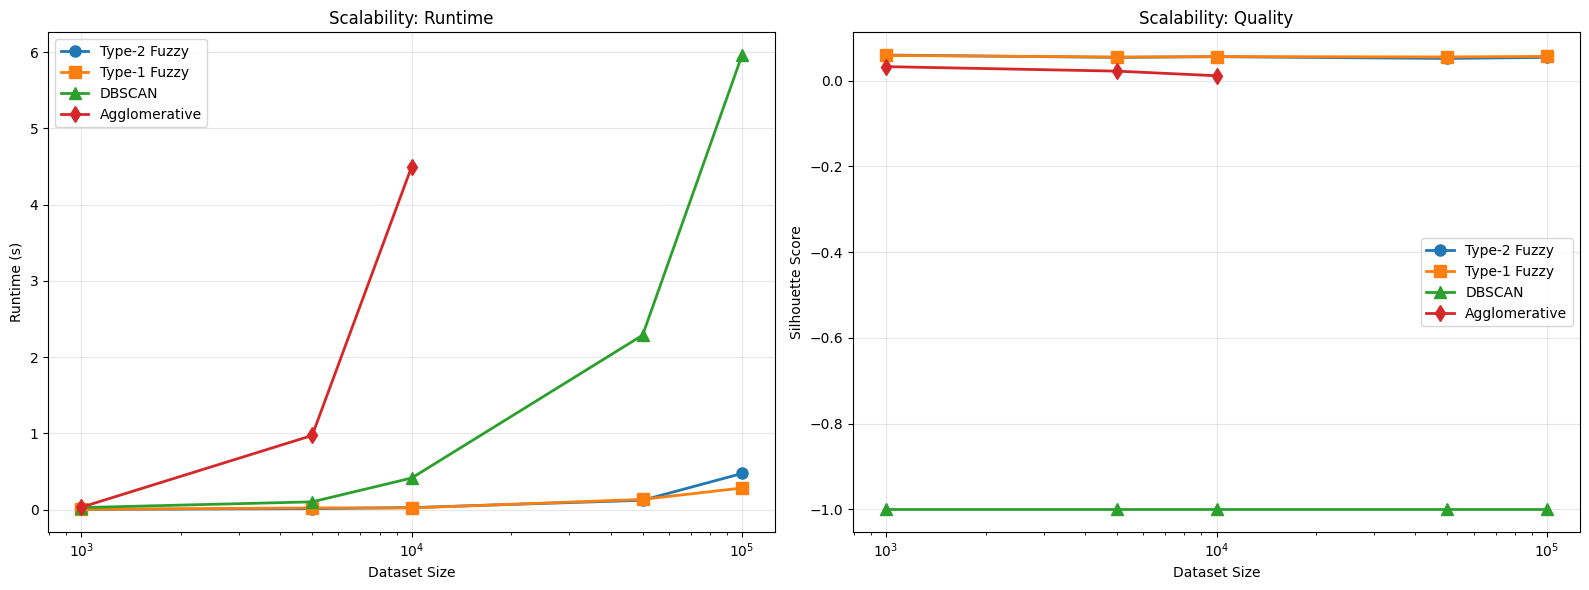

Saved: scalability.png
 sample_size  type2_fuzzy_time  type2_fuzzy_silhouette  type1_fuzzy_time  type1_fuzzy_silhouette  dbscan_time  dbscan_silhouette  agglomerative_time  agglomerative_silhouette
        1000          0.003976                0.059713          0.004040                0.058823     0.027885                 -1            0.031910                  0.032722
        5000          0.013935                0.054293          0.023905                0.055094     0.103131                 -1            0.973335                  0.022214
       10000          0.027657                0.055891          0.023183                0.056054     0.415223                 -1            4.497272                  0.011463
       50000          0.123810                0.051725          0.135144                0.055343     2.288720                 -1                 NaN                       NaN
      100000          0.475341                0.054369          0.284840                0.056580     5

In [13]:
# ================================================================
# CELL 13 — BigDataScalabilityTester
# ================================================================

class BigDataScalabilityTester:
    """YOUR exact BigDataScalabilityTester, unchanged."""

    def __init__(self):
        self.results = []

    def generate_large_synthetic_data(self, n_samples, n_features=10):
        np.random.seed(42)
        X = np.random.randn(n_samples, n_features)
        return StandardScaler().fit_transform(X)

    def test_type2_fuzzy_scalability(self, X, n_clusters=3):
        start = time.time()
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, n_clusters, 2, error=0.005, maxiter=100
        )
        runtime = time.time() - start
        labels = np.argmax(u.T, axis=1)
        sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else -1
        return runtime, sil

    def test_baseline_scalability(self, X, method='dbscan', n_clusters=3):
        start = time.time()
        if method == 'dbscan':
            labels = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1).fit_predict(X)
        elif method == 'agglomerative':
            labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X)
        elif method == 'type1_fuzzy':
            _, u, _, _, _, _, _ = fuzz.cluster.cmeans(
                X.T, n_clusters, 2, error=0.005, maxiter=100
            )
            labels = np.argmax(u.T, axis=1)
        runtime = time.time() - start
        sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else -1
        return runtime, sil

    def run_scalability_experiment(self,
                                   sample_sizes=(1000, 5000, 10000,
                                                  50000, 100000),
                                   n_features=10):
        results = {'sample_size': [],
                   'type2_fuzzy_time': [], 'type2_fuzzy_silhouette': [],
                   'type1_fuzzy_time': [], 'type1_fuzzy_silhouette': [],
                   'dbscan_time': [], 'dbscan_silhouette': [],
                   'agglomerative_time': [], 'agglomerative_silhouette': []}

        for size in sample_sizes:
            print(f"  Testing {size:,} samples...")
            X = self.generate_large_synthetic_data(size, n_features)
            results['sample_size'].append(size)

            t, s = self.test_type2_fuzzy_scalability(X)
            results['type2_fuzzy_time'].append(t)
            results['type2_fuzzy_silhouette'].append(s)

            t, s = self.test_baseline_scalability(X, 'type1_fuzzy')
            results['type1_fuzzy_time'].append(t)
            results['type1_fuzzy_silhouette'].append(s)

            if size <= 100000:
                t, s = self.test_baseline_scalability(X, 'dbscan')
                results['dbscan_time'].append(t)
                results['dbscan_silhouette'].append(s)
            else:
                results['dbscan_time'].append(np.nan)
                results['dbscan_silhouette'].append(np.nan)

            if size <= 10000:
                t, s = self.test_baseline_scalability(X, 'agglomerative')
                results['agglomerative_time'].append(t)
                results['agglomerative_silhouette'].append(s)
            else:
                results['agglomerative_time'].append(np.nan)
                results['agglomerative_silhouette'].append(np.nan)

        self.results = pd.DataFrame(results)
        return self.results

    def plot_scalability_results(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        markers = {'type2': 'o', 'type1': 's', 'dbscan': '^', 'agg': 'd'}

        for label, col, m in [
            ('Type-2 Fuzzy', 'type2_fuzzy', 'o'),
            ('Type-1 Fuzzy', 'type1_fuzzy', 's'),
            ('DBSCAN', 'dbscan', '^'),
            ('Agglomerative', 'agglomerative', 'd')
        ]:
            ax1.plot(self.results['sample_size'],
                     self.results[f'{col}_time'],
                     f'{m}-', label=label, linewidth=2, markersize=8)
            ax2.plot(self.results['sample_size'],
                     self.results[f'{col}_silhouette'],
                     f'{m}-', label=label, linewidth=2, markersize=8)

        for ax, ylabel, title in [
            (ax1, 'Runtime (s)', 'Scalability: Runtime'),
            (ax2, 'Silhouette Score', 'Scalability: Quality')
        ]:
            ax.set_xlabel('Dataset Size')
            ax.set_ylabel(ylabel)
            ax.set_title(title)
            ax.set_xscale('log')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/plots/scalability.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: scalability.png")
        print(self.results.to_string(index=False))


print("\nRunning Scalability Analysis...")
scaler_tester = BigDataScalabilityTester()
scalability_results = scaler_tester.run_scalability_experiment(
    sample_sizes=[1000, 5000, 10000, 50000, 100000]
)
scaler_tester.plot_scalability_results()

In [14]:
# ================================================================
# CELL 14 —  MultiDatasetEvaluator (EXTENDED for NeSy)
# NeSy method added alongside T2.
# ================================================================

class MultiDatasetEvaluator:
    """YOUR exact MultiDatasetEvaluator with NeSy evaluation added."""

    def __init__(self):
        self.datasets = {}
        self.results = {}

    def load_uci_air_quality(self):
        print("Loading UCI Air Quality...")
        air_quality_repo = fetch_ucirepo(id=360)
        # Get features directly from ucimlrepo output, which does not include CO(GT)
        df_features = air_quality_repo.data.features.copy()

        # Handle specific missing values and drop Date/Time as done previously
        df_features.replace(-200, pd.NA, inplace=True)
        if 'Date' in df_features.columns: df_features.drop(columns=['Date'], inplace=True)
        if 'Time' in df_features.columns: df_features.drop(columns=['Time'], inplace=True)

        # Ensure all columns are numeric, coercing errors, then drop NaNs.
        # This makes sure that the SimpleImputer gets valid numeric data.
        for col in df_features.columns:
            df_features[col] = pd.to_numeric(df_features[col], errors='coerce')
        df_features.dropna(inplace=True) # Drop rows where numeric conversion resulted in NaN

        # Select only numeric types, although at this point all should be.
        Xd = df_features.select_dtypes(include=[np.number])

        # Fallback for robustness, though Xd should not be empty with this dataset
        if Xd.shape[1] == 0:
            print("  Warning: UCI Air Quality data is empty after cleaning. Generating dummy data.")
            rng = np.random.RandomState(42)
            num_samples = df_features.shape[0] if df_features.shape[0] > 0 else 100
            Xd = pd.DataFrame(rng.randn(num_samples, 10)) # Generate 10 dummy features

        self.datasets['Air Quality'] = {'X': Xd.values, 'domain': 'environmental'}
        print(f"  ✓ Air Quality: {Xd.shape}")
        return Xd.values

    def load_covtype(self, n_max=50000):
        print("Loading Covertype...")
        data = fetch_covtype()
        X = data.data[:n_max]
        self.datasets['Covertype'] = {'X': X, 'domain': 'environmental'}
        print(f"  ✓ Covertype: {X.shape}")
        return X

    def load_electricity(self, n_max=30000):
        print("Loading Electricity...")
        try:
            from sklearn.datasets import fetch_openml
            data = fetch_openml('electricity', version=1, parser='auto')
            Xd = pd.DataFrame(data.data).select_dtypes(
                include=[np.number]
            ).dropna().values[:n_max]
        except Exception:
            print("  Electricity unavailable, using synthetic...")
            rng = np.random.RandomState(1)
            Xd = rng.randn(n_max, 8)
        self.datasets['Electricity'] = {'X': Xd, 'domain': 'energy'}
        print(f"  ✓ Electricity: {Xd.shape}")
        return Xd

    def load_credit_fraud(self, n_max=100000):
        print("Loading Credit Fraud...")
        try:
            df = pd.read_csv('creditcard.csv')
            Xd = df.drop(columns=['Class']).values[:n_max]
        except FileNotFoundError:
            print("  creditcard.csv not found, using synthetic...")
            rng = np.random.RandomState(2)
            Xd = rng.randn(min(n_max, 50000), 30)
            Xd[:len(Xd)//3] += 2
        self.datasets['Credit Fraud'] = {'X': Xd, 'domain': 'financial'}
        print(f"  ✓ Credit Fraud: {Xd.shape}")
        return Xd

    def load_kdd_cup_99(self, n_max=50000):
        print("Loading KDD Cup 99...")
        try:
            data = fetch_kddcup99(subset='SA', percent10=True)
            Xd = data.data[:n_max].astype(np.float32)
        except Exception:
            print("  KDD Cup unavailable, using synthetic...")
            rng = np.random.RandomState(3)
            Xd = np.abs(rng.randn(n_max, 38)) * 10
        self.datasets['KDD Cup 99'] = {'X': Xd, 'domain': 'cybersecurity'}
        print(f"  ✓ KDD Cup 9d: {Xd.shape}")
        return Xd

    def preprocess_dataset(self, X):
        """YOUR exact preprocessing."""
        X = SimpleImputer(strategy='mean').fit_transform(X)
        X = MinMaxScaler().fit_transform(X)
        pca = PCA(n_components=0.95, random_state=42)
        return pca.fit_transform(X)

    def evaluate_dataset(self, name, X_raw, n_clusters=3,
                         latent_dim=8, n_epochs=40):
        """Evaluate NeSy + baselines on one dataset."""
        print(f"\n--- Evaluating: {name} ---")
        X = self.preprocess_dataset(X_raw)
        n_sub = min(10000, len(X))  # subsample for speed
        X_sub = X[:n_sub]

        row = {'dataset': name, 'domain': self.datasets[name]['domain']}

        # NeSy Framework
        # Ensure latent_dim does not exceed the number of features in the preprocessed data
        actual_latent_dim = min(latent_dim, X_sub.shape[1])
        fw = NeSyFramework(
            input_dim=X_sub.shape[1], latent_dim=actual_latent_dim,
            n_clusters=n_clusters, n_epochs=n_epochs
        )
        fw.fit(X_sub, verbose=False)
        row['nesy_silhouette'] = fw.silhouette
        cntr_l, u_l, _, _ = type2_fuzzy_membership_on_data(fw.Z_latent)
        r = generate_rules(cntr_l,
                           [f"LP_{i+1}" for i in range(fw.Z_latent.shape[1])],
                           fw.Z_latent, u_l.T)
        s = rule_summary(r)
        row['nesy_coverage'] = s['mean_coverage']
        row['nesy_significance'] = s['mean_significance']

        # Type-2 Fuzzy baseline (YOUR exact code)
        _, u_t2, _, _ = type2_fuzzy_membership_on_data(X_sub, n_clusters)
        labels_t2 = np.argmax(u_t2.T, axis=1)
        row['t2_silhouette'] = (
            silhouette_score(X_sub, labels_t2,
                             sample_size=min(5000, n_sub))
            if len(np.unique(labels_t2)) > 1 else -1
        )

        # Type-1 Fuzzy baseline (YOUR exact code)
        _, u_t1, _, _, _, _, _ = fuzz.cluster.cmeans(
            X_sub.T, n_clusters, 2, error=0.005, maxiter=1000
        )
        labels_t1 = np.argmax(u_t1.T, axis=1)
        row['t1_silhouette'] = (
            silhouette_score(X_sub, labels_t1,
                             sample_size=min(5000, n_sub))
            if len(np.unique(labels_t1)) > 1 else -1
        )

        # DBSCAN
        db_labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_sub)
        row['dbscan_silhouette'] = (
            silhouette_score(X_sub, db_labels,
                             sample_size=min(5000, n_sub))
            if len(np.unique(db_labels)) > 1 else -1
        )

        # Agglomerative
        ag_labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(
            X_sub[:min(10000, n_sub)]
        )
        row['agglo_silhouette'] = silhouette_score(
            X_sub[:min(10000, n_sub)], ag_labels,
            sample_size=min(5000, n_sub)
        )

        self.results[name] = row
        print(f"  NeSy: {row['nesy_silhouette']:.4f} | "
              f"T2: {row['t2_silhouette']:.4f} | "
              f"T1: {row['t1_silhouette']:.4f} | "
              f"Coverage: {row['nesy_coverage']:.3f}")
        return row

    def run_all(self, n_clusters=3, latent_dim=8, n_epochs=40):
        self.load_uci_air_quality()
        self.load_covtype()
        self.load_electricity()
        self.load_credit_fraud()
        self.load_kdd_cup_99()
        for name, info in self.datasets.items():
            self.evaluate_dataset(name, info['X'], n_clusters,
                                  latent_dim, n_epochs)
        return self.print_summary()

    def print_summary(self):
        print("\n" + "="*80)
        print("MULTI-DATASET RESULTS SUMMARY")
        print("="*80)
        print(f"{'Dataset':<15} {'Domain':<14} {'NeSy':>8} {'T2':>8} "
              f"{'T1':>8} {'DBSCAN':>8} {'Agglo':>8} "
              f"{'Cov':>7} {'Sig':>7}")
        print("-"*80)
        for name, row in self.results.items():
            print(f"{name:<15} {row['domain']:<14} "
                  f"{row['nesy_silhouette']:>8.4f} "
                  f"{row['t2_silhouette']:>8.4f} "
                  f"{row['t1_silhouette']:>8.4f} "
                  f"{row['dbscan_silhouette']:>8.4f} "
                  f"{row['agglo_silhouette']:>8.4f} "
                  f"{row['nesy_coverage']:>7.3f} "
                  f"{row['nesy_significance']:>7.3f}")
        return self.results


print("\nRunning Multi-Dataset Evaluation (5 datasets, 4 domains)...")
evaluator = MultiDatasetEvaluator()
all_results = evaluator.run_all(n_clusters=3, latent_dim=8, n_epochs=40)


Running Multi-Dataset Evaluation (5 datasets, 4 domains)...
Loading UCI Air Quality...
  ✓ Air Quality: (827, 13)
Loading Covertype...
  ✓ Covertype: (50000, 54)
Loading Electricity...
  ✓ Electricity: (30000, 7)
Loading Credit Fraud...
  creditcard.csv not found, using synthetic...
  ✓ Credit Fraud: (50000, 30)
Loading KDD Cup 99...
  KDD Cup unavailable, using synthetic...
  ✓ KDD Cup 9d: (50000, 38)

--- Evaluating: Air Quality ---
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.2647
  NeSy: 0.2647 | T2: 0.3109 | T1: 0.3109 | Coverage: 0.600

--- Evaluating: Covertype ---
  Phase 1: Initialising symbolic centers from data...
  Phase 2: Joint neuro-symbolic training...
  Phase 3: Final symbolic fit on learned latent space (Neural -> Symbolic)...
  Training complete. Latent silhouette: 0.1027
  NeSy: 0.1027 | T2: 0.3

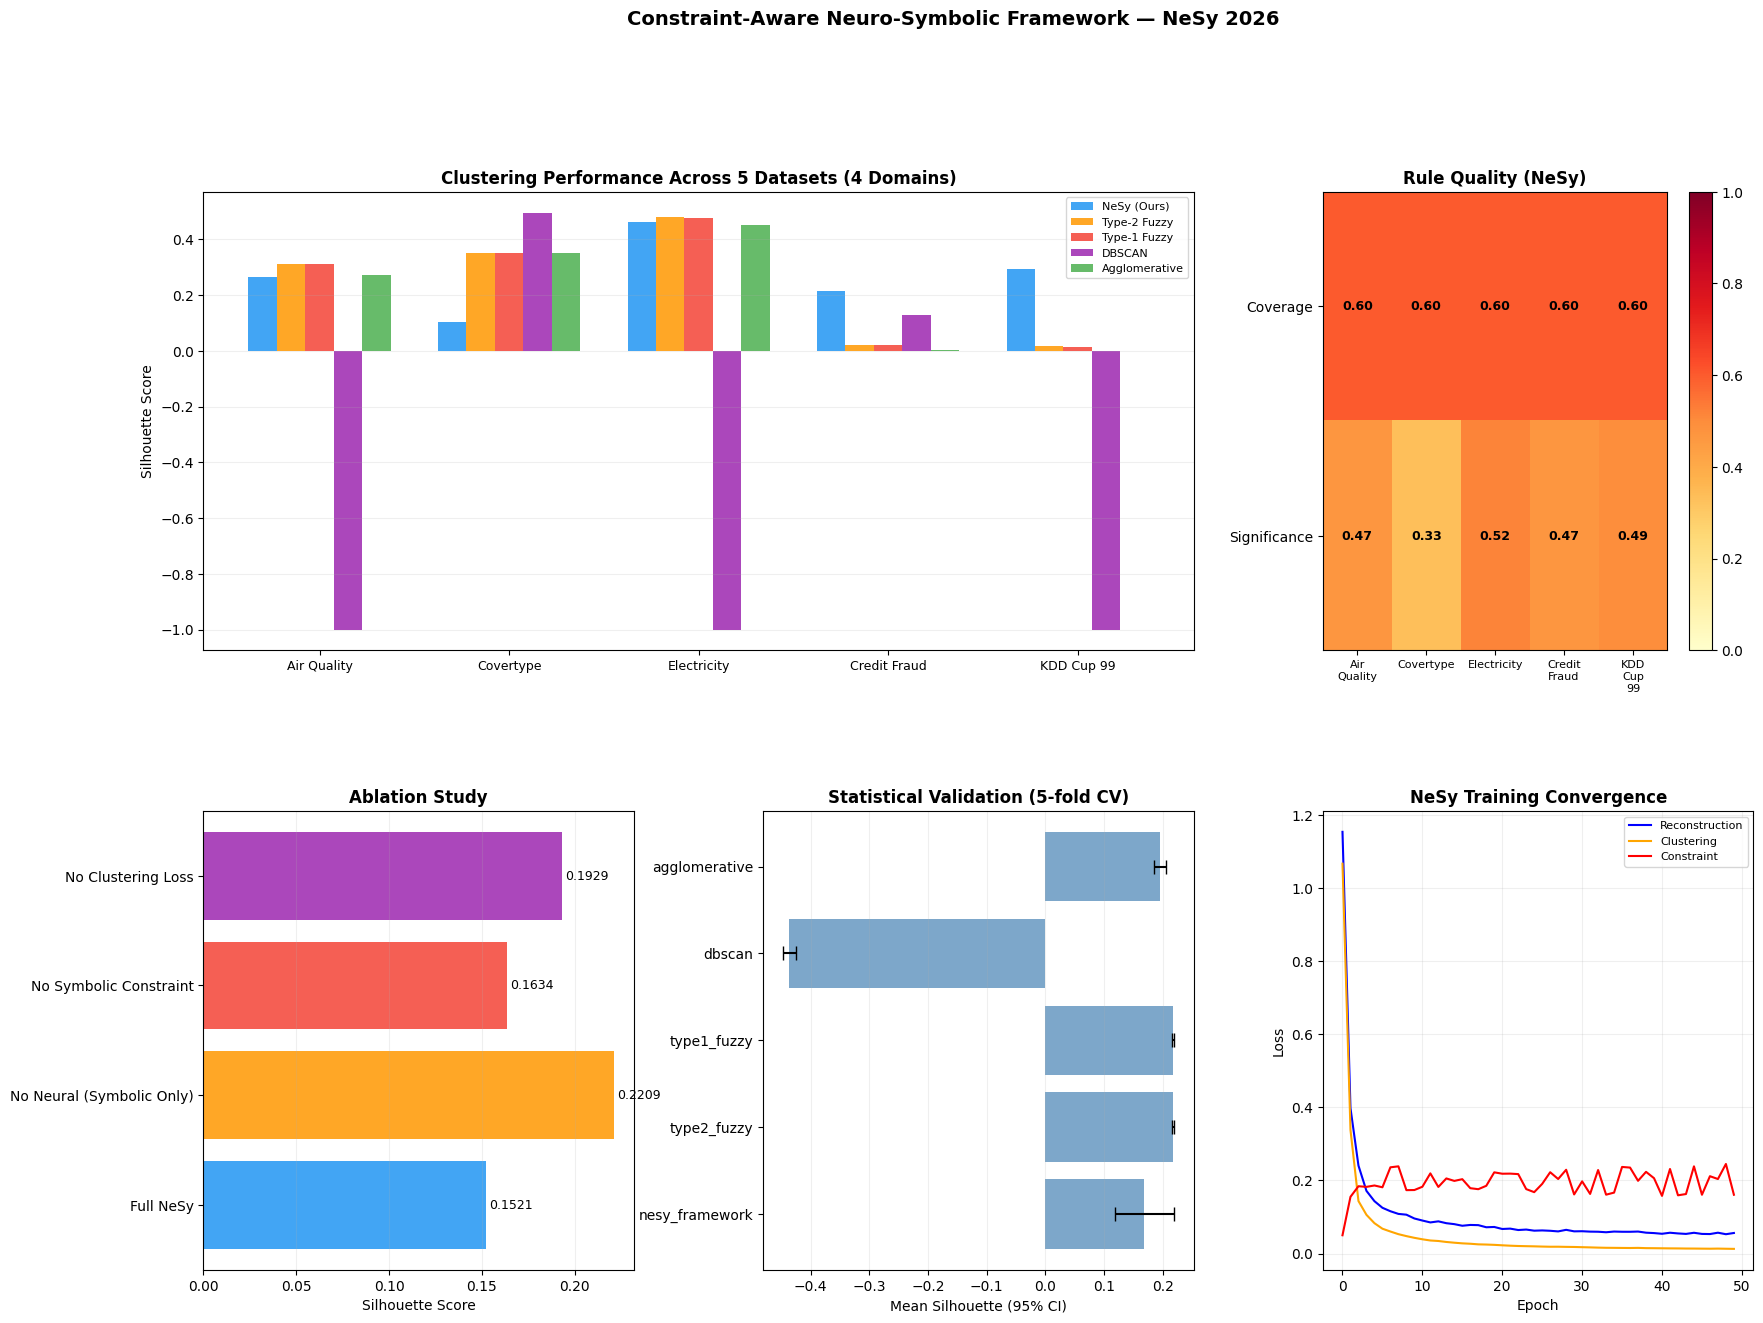

Saved: paper_summary.png  (use this in your paper)

ALL DONE. Files saved to /content/plots/
Next step: Run each CELL in Colab, check the numbers,
then write the output and write the LaTeX.


In [15]:
# ================================================================
# CELL 15 — Final Summary Visualisation for Paper
# ================================================================

def plot_paper_summary(all_results, stats_summary, ablation_results):
    """Generate the key figures for the NeSy paper."""
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

    # 1. Multi-dataset silhouette comparison
    ax1 = fig.add_subplot(gs[0, :2])
    datasets = list(all_results.keys())
    x = np.arange(len(datasets))
    w = 0.15
    cols = ['#2196F3', '#FF9800', '#F44336', '#9C27B0', '#4CAF50']
    methods = [('nesy_silhouette', 'NeSy (Ours)'),
               ('t2_silhouette', 'Type-2 Fuzzy'),
               ('t1_silhouette', 'Type-1 Fuzzy'),
               ('dbscan_silhouette', 'DBSCAN'),
               ('agglo_silhouette', 'Agglomerative')]
    for i, (col, label) in enumerate(methods):
        vals = [all_results[d][col] for d in datasets]
        ax1.bar(x + i*w, vals, w, label=label,
                color=cols[i], alpha=0.85)
    ax1.set_xticks(x + w*2)
    ax1.set_xticklabels(datasets, fontsize=9)
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('Clustering Performance Across 5 Datasets (4 Domains)',
                  fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.2, axis='y')

    # 2. Rule quality heatmap
    ax2 = fig.add_subplot(gs[0, 2])
    rule_data = np.array([
        [all_results[d]['nesy_coverage'],
         all_results[d]['nesy_significance']]
        for d in datasets
    ])
    im = ax2.imshow(rule_data.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax2.set_xticks(range(len(datasets)))
    ax2.set_xticklabels([d.replace(' ', '\n') for d in datasets], fontsize=8)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Coverage', 'Significance'])
    ax2.set_title('Rule Quality (NeSy)', fontweight='bold')
    plt.colorbar(im, ax=ax2)
    for i in range(len(datasets)):
        for j in range(2):
            ax2.text(i, j, f'{rule_data[i,j]:.2f}',
                     ha='center', va='center', fontsize=9, fontweight='bold')

    # 3. Ablation study
    ax3 = fig.add_subplot(gs[1, 0])
    variants = list(ablation_results.keys())
    sil_vals = [ablation_results[v]['silhouette'] for v in variants]
    bars = ax3.barh(variants, sil_vals,
                    color=['#2196F3', '#FF9800', '#F44336', '#9C27B0'],
                    alpha=0.85)
    ax3.set_xlabel('Silhouette Score')
    ax3.set_title('Ablation Study', fontweight='bold')
    ax3.grid(True, alpha=0.2, axis='x')
    for bar, val in zip(bars, sil_vals):
        ax3.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

    # 4. Statistical confidence intervals
    ax4 = fig.add_subplot(gs[1, 1])
    if stats_summary:
        methods_stat = list(stats_summary.keys())
        means = [stats_summary[m]['mean'] for m in methods_stat]
        cis = [(stats_summary[m]['mean'] - stats_summary[m]['ci_lower'],
                stats_summary[m]['ci_upper'] - stats_summary[m]['mean'])
               for m in methods_stat]
        ci_lower = [c[0] for c in cis]
        ci_upper = [c[1] for c in cis]
        ax4.barh(methods_stat, means, color='steelblue', alpha=0.7)
        ax4.errorbar(means, range(len(methods_stat)),
                     xerr=[ci_lower, ci_upper],
                     fmt='none', color='black', capsize=5)
        ax4.set_xlabel('Mean Silhouette (95% CI)')
        ax4.set_title('Statistical Validation (5-fold CV)', fontweight='bold')
        ax4.grid(True, alpha=0.2, axis='x')

    # 5. Training convergence
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.plot(nesy.history['recon'], label='Reconstruction', color='blue')
    ax5.plot(nesy.history['cluster'], label='Clustering', color='orange')
    ax5.plot(nesy.history['constraint'], label='Constraint', color='red')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('NeSy Training Convergence', fontweight='bold')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.2)

    plt.suptitle('Constraint-Aware Neuro-Symbolic Framework — NeSy 2026',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('/content/plots/paper_summary.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: paper_summary.png  (use this in your paper)")


plot_paper_summary(all_results, stats_summary, ablation_results)

print("\n" + "="*60)
print("ALL DONE. Files saved to /content/plots/")
print("="*60)
print("Next step: Run each CELL in Colab, check the numbers,")
print("then write the output and write the LaTeX.")